 ### In this notebook, the performance differences between
#### classification methods in Python will be examined. First, the datawill be cleaned and prepared for modeling.*



### Dataset:
#### <https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval>*

-   *The dataset contains approximately 36 variables. These are:*

-   ApplicationDate: Date the loan was applied for
-   Age: Age of the applicant
-   AnnualIncome: Annual income
-   CreditScore: Credit Score
-   EmploymentStatus: Employment status
-   EducationLevel: Highest level of education completed
-   Experience: Work experience
-   LoanAmount: Requested loan amount
-   LoanDuration: Repayment period
-   MaritalStatus: Marital status
-   NumberOfDependents: Number of dependents
-   HomeOwnershipStatus: House ownership Flag
-   MonthlyDebtPayments: Monthly debt payment amount
-   CreditCardUtilizationRate: Credit card utilization rate
-   NumberOfOpenCreditLines: Number of active credit lines
-   NumberOfCreditInquiries: Number of credit inquiries
-   DebtToIncomeRatio: Debt-to-income ratio
-   BankruptcyHistory: Whether the applicant has a history of bankruptcy
-   LoanPurpose: Purpose of the loan
-   PreviousLoanDefaults: Previous loan defaults
-   PaymentHistory: History of previous loan payments
-   LengthOfCreditHistory: Length of credit history
-   SavingsAccountBalance: Savings account balance
-   CheckingAccountBalance: Checking account balance
-   TotalAssets: Total assets owned
-   TotalLiabilities: Total liabilities
-   MonthlyIncome: Monthly income
-   UtilityBillsPaymentHistory: Utility bills payment history
-   JobTenure: Job tenure
-   NetWorth: Total net worth of the applicant
-   BaseInterestRate: Base interest rate
-   InterestRate: Working Interest Rate
-   MonthlyLoanPayment: Monthly loan payment amount
-   TotalDebtToIncomeRatio: Total debt-to-income ratio
-   LoanApproved: Loan approval status
-   RiskScore: Risk Score

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sb
import warnings
warnings.filterwarnings('ignore')

In [66]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("lorenzozoppelletto/financial-risk-for-loan-approval")

print("Path to dataset files:", path)

print("Files in dataset:", os.listdir(path))

Path to dataset files: /Users/furkancanercan/.cache/kagglehub/datasets/lorenzozoppelletto/financial-risk-for-loan-approval/versions/2
Files in dataset: ['Loan.csv', 'CSV Generation.py']


In [67]:
file_path = os.path.join(path, "Loan.csv")
data = pd.read_csv(file_path)

In [68]:
data.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


```
|     | ApplicationDate | Age | AnnualIncome | CreditScore | EmploymentStatus | EducationLevel | Experience | LoanAmount | LoanDuration | MaritalStatus | ... | MonthlyIncome | UtilityBillsPaymentHistory | JobTenure | NetWorth | BaseInterestRate | InterestRate | MonthlyLoanPayment | TotalDebtToIncomeRatio | LoanApproved | RiskScore |
|-----|-----------------|-----|--------------|-------------|------------------|----------------|------------|------------|--------------|---------------|-----|---------------|----------------------------|-----------|----------|------------------|--------------|--------------------|------------------------|--------------|-----------|
| 0   | 2018-01-01      | 45  | 39948        | 617         | Employed         | Master         | 22         | 13152      | 48           | Married       | ... | 3329.000000   | 0.724972                   | 11        | 126928   | 0.199652         | 0.227590     | 419.805992         | 0.181077               | 0            | 49.0      |
| 1   | 2018-01-02      | 38  | 39709        | 628         | Employed         | Associate      | 15         | 26045      | 48           | Single        | ... | 3309.083333   | 0.935132                   | 3         | 43609    | 0.207045         | 0.201077     | 794.054238         | 0.389852               | 0            | 52.0      |
| 2   | 2018-01-03      | 47  | 40724        | 570         | Employed         | Bachelor       | 26         | 17627      | 36           | Married       | ... | 3393.666667   | 0.872241                   | 6         | 5205     | 0.217627         | 0.212548     | 666.406688         | 0.462157               | 0            | 52.0      |
| 3   | 2018-01-04      | 58  | 69084        | 545         | Employed         | High School    | 34         | 37898      | 96           | Single        | ... | 5757.000000   | 0.896155                   | 5         | 99452    | 0.300398         | 0.300911     | 1047.506980        | 0.313098               | 0            | 54.0      |
| 4   | 2018-01-05      | 37  | 103264       | 594         | Employed         | Associate      | 17         | 9184       | 36           | Married       | ... | 8605.333333   | 0.941369                   | 5         | 227019   | 0.197184         | 0.175990     | 330.179140         | 0.070210               | 1            | 36.0      |

5 rows × 36 columns
```

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

### Missing Value Check

In [70]:
data.isnull().any().sum()

np.int64(0)

```
0
```

##### Variables I modified and the reasons for those modifications

-   ##### ApplicationDate will not provide me with any information relevant to loan approval.

-   ##### EducationLevel'i One-hot encoding ile düzenleme sebebim mezun olunan son akademik medyumun kişinin onay oranına gözle görülür bir etkide bulunabileceğini düşünüyor olmamdı. 0'dan 4 e en düşükten yükseğe değerler atadım.

-   ##### For EmploymentStatus, I preferred an ordinal encoding where 0 means unemployed and 2 means employed.

-   ##### For MaritalStatus, I preferred to simplify it by encoding 0 as single and 1 as married.

-   ##### For HomeOwnershipStatus, I ordered housing status from renting to owning.

-   ##### Finally, since I believed the values in the LoanPurpose variable have no natural numerical ordering, I treated it as dummy variables.

In [71]:
data = data.drop("ApplicationDate",axis = 1) # Dropping ApplicationDate since it is a datetime column

In [72]:
# Encode some variables with ordinal encoding and others with get_dummies

data["EducationLevel"] = data["EducationLevel"].map({
    "High School": 0,
    "Associate": 1,
    "Bachelor": 2,
    "Master": 3,
    "Doctorate": 4
})
data["EmploymentStatus"] = data["EmploymentStatus"].map({
    "Unemployed": 0,
    "Self-Employed": 1,
    "Employed": 2
})
# I found it more appropriate to directly split MaritalStatus into married and single
data["MaritalStatus"] = data["MaritalStatus"].map({
    "Single": 0,
    "Divorced": 0,
    "Widowed": 0,
    "Married": 1
})
data["HomeOwnershipStatus"] = data["HomeOwnershipStatus"].map({
    "Other": 0,
    "Rent": 1,
    "Mortgage": 2,
    "Own": 3
})
# LoanPurpose has no natural order so we use get_dummies
loan_purpose_dummies = pd.get_dummies(data["LoanPurpose"], prefix="LoanPurpose")
data = pd.concat([data.drop("LoanPurpose", axis=1), loan_purpose_dummies], axis=1)

Text(0.5, 1.0, 'Correlation Matrix and Heatmap')

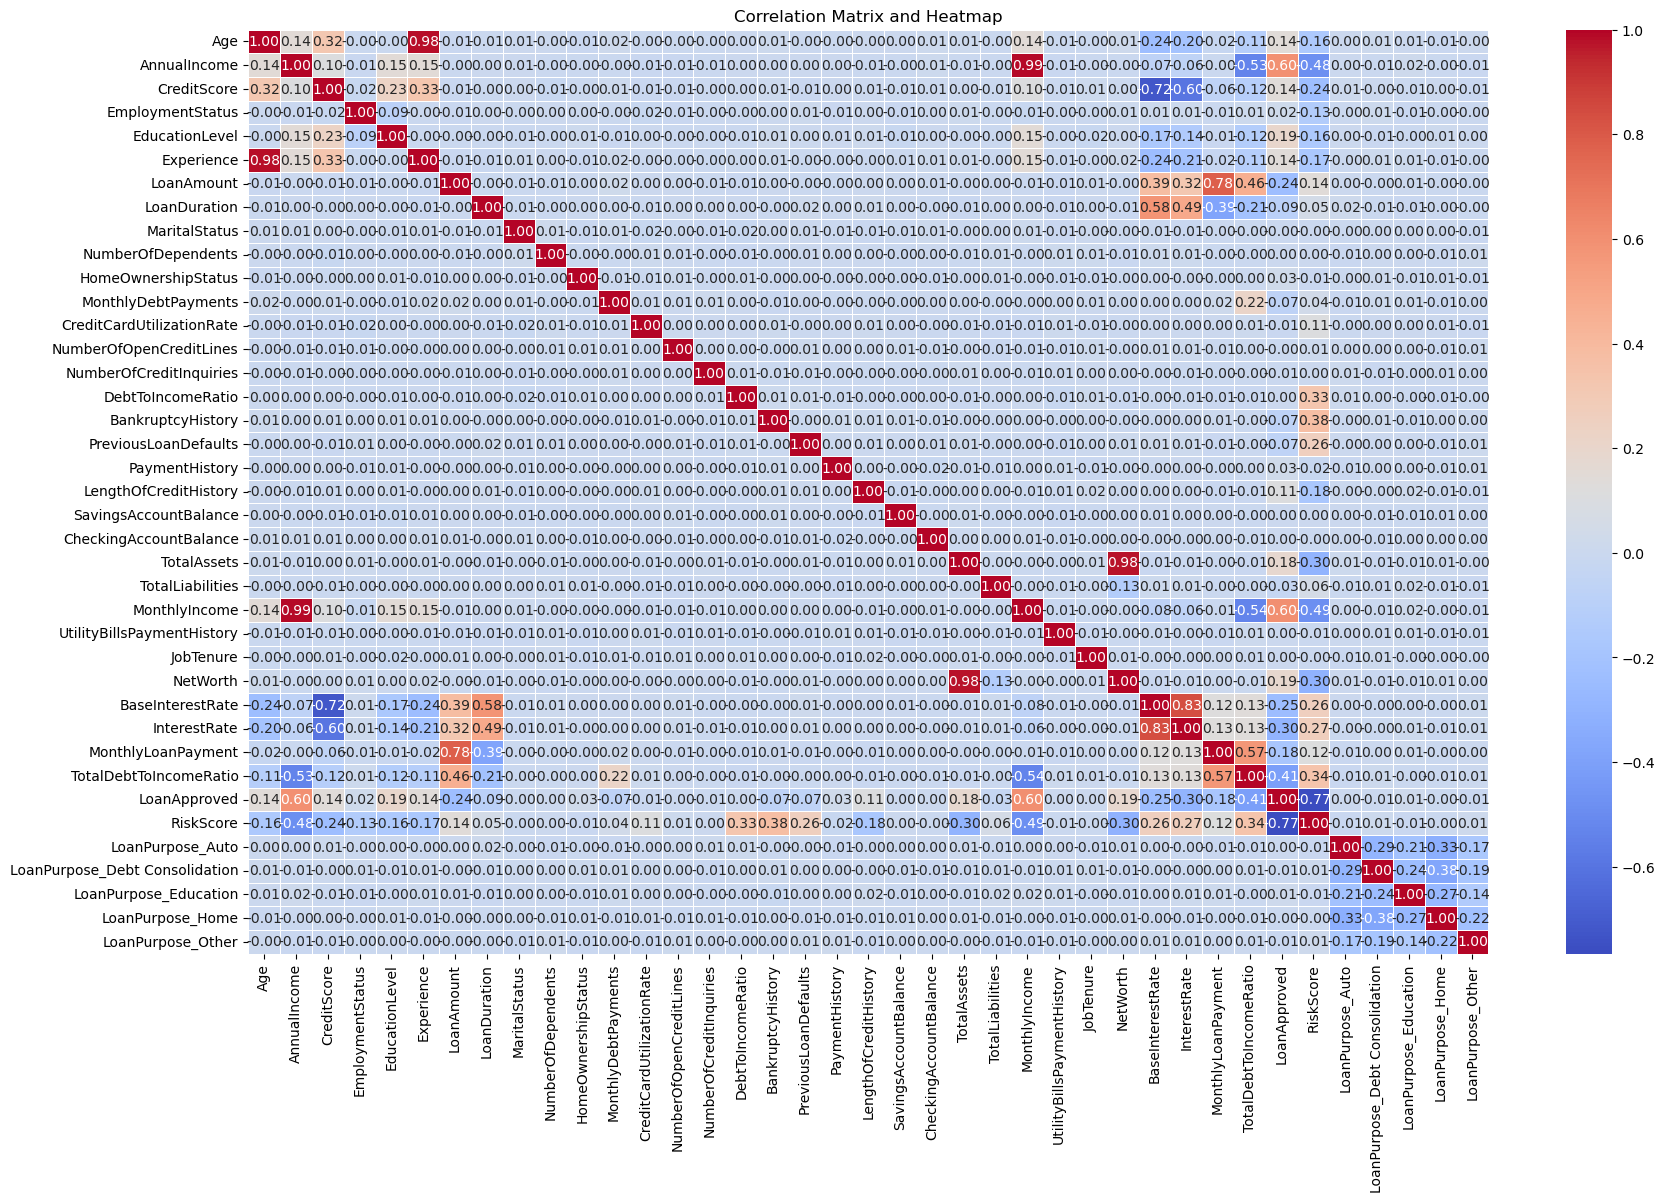

In [73]:
corr = data.corr()

mp.figure(figsize = (20,12))
sb.heatmap(corr,annot=True,cmap ="coolwarm", fmt = ".2f", linewidth = 0.6)
mp.title("Correlation Matrix and Heatmap")

```
Text(0.5, 1.0, 'Correlation Matrix and Heatmap')
```

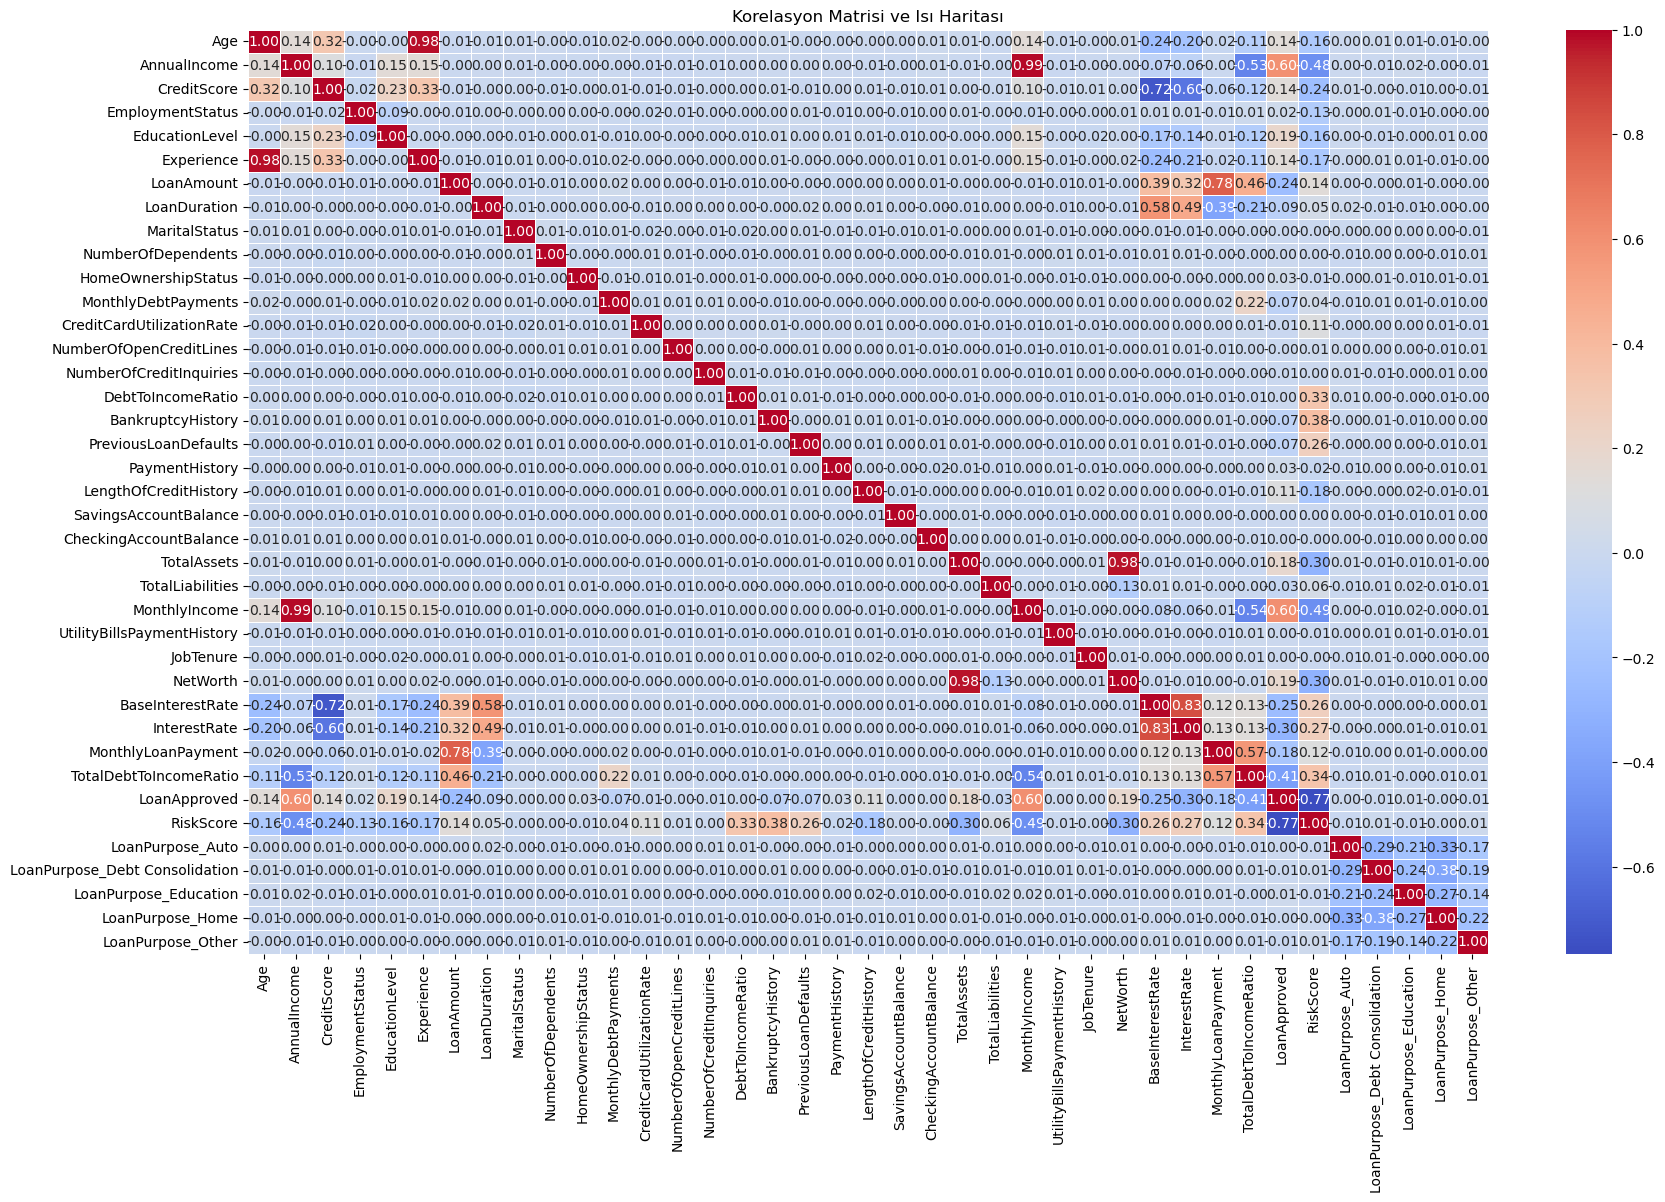

#### As can be seen from the Correlation Matrix, there is a high degree of correlation between some variables. We may encounter Multicollinearity and Data Leakage issues. Let us investigate.

#### Let us look at VIF values for Multicollinearity.

In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [75]:
x_numeric = data.select_dtypes(include = ["int64","float64"]).drop(columns = ["LoanApproved"],
                                                                   errors = "ignore")
x_numeric_const = add_constant(x_numeric)

In [76]:
vif_data = pd.DataFrame()
vif_data["feature"] = x_numeric_const.columns
vif_data["VIF"] = [variance_inflation_factor(x_numeric_const.values,i) for i in range(x_numeric_const.shape[1])]
vif_data.sort_values(by = "VIF",ascending = False)

,feature,VIF
3,CreditScore,inf
7,LoanAmount,inf
8,LoanDuration,inf
29,BaseInterestRate,inf
25,MonthlyIncome,51.419918
2,AnnualIncome,49.875086
28,NetWorth,40.747622
23,TotalAssets,39.827297
6,Experience,29.781178
1,Age,29.663656


```
|     | feature                    | VIF       |
|-----|----------------------------|-----------|
| 3   | CreditScore                | inf       |
| 7   | LoanAmount                 | inf       |
| 8   | LoanDuration               | inf       |
| 29  | BaseInterestRate           | inf       |
| 25  | MonthlyIncome              | 51.419918 |
| 2   | AnnualIncome               | 49.875086 |
| 28  | NetWorth                   | 40.747622 |
| 23  | TotalAssets                | 39.827297 |
| 6   | Experience                 | 29.781178 |
| 1   | Age                        | 29.663656 |
| 31  | MonthlyLoanPayment         | 5.041667  |
| 33  | RiskScore                  | 4.638611  |
| 30  | InterestRate               | 3.477135  |
| 32  | TotalDebtToIncomeRatio     | 2.903183  |
| 24  | TotalLiabilities           | 1.684188  |
| 17  | BankruptcyHistory          | 1.668244  |
| 16  | DebtToIncomeRatio          | 1.473361  |
| 18  | PreviousLoanDefaults       | 1.325223  |
| 20  | LengthOfCreditHistory      | 1.156012  |
| 12  | MonthlyDebtPayments        | 1.135400  |
| 5   | EducationLevel             | 1.123569  |
| 4   | EmploymentStatus           | 1.104312  |
| 13  | CreditCardUtilizationRate  | 1.046106  |
| 19  | PaymentHistory             | 1.003062  |
| 11  | HomeOwnershipStatus        | 1.002609  |
| 9   | MaritalStatus              | 1.002019  |
| 26  | UtilityBillsPaymentHistory | 1.002011  |
| 27  | JobTenure                  | 1.001821  |
| 21  | SavingsAccountBalance      | 1.001597  |
| 14  | NumberOfOpenCreditLines    | 1.001324  |
| 10  | NumberOfDependents         | 1.001311  |
| 22  | CheckingAccountBalance     | 1.001012  |
| 15  | NumberOfCreditInquiries    | 1.000951  |
| 0   | const                      | 0.000000  |
```

#### The error I encountered while examining VIF values indicates that some variables have an R² of 1, causing a division-by-zero situation. Some combined variables may be producing R² = 1 together. Bundan dolayı manuel olarak onları çıkartıp tekrar vif değerlerine bakalım

In [77]:
drop_inf_cols = [
    'CreditScore',
    'LoanAmount',
    'LoanDuration',
    'BaseInterestRate'
]
numeric_data = data.select_dtypes(include=['int64', 'float64']).drop(columns=['LoanApproved'], errors='ignore')

# Remove only columns with inf values
x_base = numeric_data.drop(columns=drop_inf_cols, errors='ignore')
x_vif = add_constant(x_base)

# VIF hesapla
vif_data = pd.DataFrame()
vif_data["feature"] = x_vif.columns
vif_data["VIF"] = [variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])]

# Sort results
print(vif_data.sort_values(by="VIF", ascending=False))


                       feature         VIF
0                        const  448.563496
22               MonthlyIncome   51.410537
2                 AnnualIncome   49.873933
25                    NetWorth   40.741769
20                 TotalAssets   39.826643
5                   Experience   29.728281
1                          Age   29.661389
29                   RiskScore    4.596841
28      TotalDebtToIncomeRatio    2.899291
27          MonthlyLoanPayment    1.955184
21            TotalLiabilities    1.684150
14           BankruptcyHistory    1.660861
13           DebtToIncomeRatio    1.469022
15        PreviousLoanDefaults    1.322811
26                InterestRate    1.274973
17       LengthOfCreditHistory    1.154760
9          MonthlyDebtPayments    1.134767
3             EmploymentStatus    1.103637
4               EducationLevel    1.087772
10   CreditCardUtilizationRate    1.045978
16              PaymentHistory    1.003009
8          HomeOwnershipStatus    1.002317
6          

#### Inf değerleri çıkardıktan sonra incelediğimizde VIF \> 10 değerinde değişkenlerimizin olduğunu görüyoruz bunların bazılarını çıkartarak yolumuza devam edelim

In [ ]:
drop_cols = [
    'CreditScore', 'LoanAmount', 'LoanDuration', 'BaseInterestRate',
    'MonthlyIncome', 'NetWorth', 'Experience'
]  

   ###### Monthly Income Annual Income ile benzer
   ###### Monthly Income Annual Income ile benzer
   ###### Monthly Income Annual Income ile benzer

   ###### NetWorth Total assets ile benzer

   ###### Experience is similar to Age in some respects.


In [79]:
x_base = data.select_dtypes(include=['int64', 'float64']).drop(columns=['LoanApproved'], errors='ignore')
x_cleaned = x_base.drop(columns=drop_cols, errors='ignore')


x_vif_updated = add_constant(x_cleaned)

vif_data_updated = pd.DataFrame()
vif_data_updated["feature"] = x_vif_updated.columns
vif_data_updated["VIF"] = [variance_inflation_factor(x_vif_updated.values, i) for i in range(x_vif_updated.shape[1])]

vif_data_updated.sort_values(by="VIF", ascending=False)

,feature,VIF
0,const,356.424730
26,RiskScore,4.504363
25,TotalDebtToIncomeRatio,2.851676
2,AnnualIncome,2.738547
24,MonthlyLoanPayment,1.937431
13,BankruptcyHistory,1.647510
12,DebtToIncomeRatio,1.460684
19,TotalAssets,1.389673
14,PreviousLoanDefaults,1.314833
23,InterestRate,1.269561


```
|     | feature                    | VIF        |
|-----|----------------------------|------------|
| 0   | const                      | 356.424730 |
| 26  | RiskScore                  | 4.504363   |
| 25  | TotalDebtToIncomeRatio     | 2.851676   |
| 2   | AnnualIncome               | 2.738547   |
| 24  | MonthlyLoanPayment         | 1.937431   |
| 13  | BankruptcyHistory          | 1.647510   |
| 12  | DebtToIncomeRatio          | 1.460684   |
| 19  | TotalAssets                | 1.389673   |
| 14  | PreviousLoanDefaults       | 1.314833   |
| 23  | InterestRate               | 1.269561   |
| 16  | LengthOfCreditHistory      | 1.151262   |
| 8   | MonthlyDebtPayments        | 1.130620   |
| 3   | EmploymentStatus           | 1.101752   |
| 4   | EducationLevel             | 1.087657   |
| 1   | Age                        | 1.082395   |
| 9   | CreditCardUtilizationRate  | 1.045385   |
| 20  | TotalLiabilities           | 1.014106   |
| 15  | PaymentHistory             | 1.002767   |
| 7   | HomeOwnershipStatus        | 1.002051   |
| 5   | MaritalStatus              | 1.001775   |
| 21  | UtilityBillsPaymentHistory | 1.001544   |
| 22  | JobTenure                  | 1.001496   |
| 10  | NumberOfOpenCreditLines    | 1.001132   |
| 6   | NumberOfDependents         | 1.000972   |
| 17  | SavingsAccountBalance      | 1.000952   |
| 18  | CheckingAccountBalance     | 1.000808   |
| 11  | NumberOfCreditInquiries    | 1.000728   |
```

In [80]:
data = data.drop(columns = drop_cols)

In [81]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  int64  
 1   AnnualIncome                    20000 non-null  int64  
 2   EmploymentStatus                20000 non-null  int64  
 3   EducationLevel                  20000 non-null  int64  
 4   MaritalStatus                   20000 non-null  int64  
 5   NumberOfDependents              20000 non-null  int64  
 6   HomeOwnershipStatus             20000 non-null  int64  
 7   MonthlyDebtPayments             20000 non-null  int64  
 8   CreditCardUtilizationRate       20000 non-null  float64
 9   NumberOfOpenCreditLines         20000 non-null  int64  
 10  NumberOfCreditInquiries         20000 non-null  int64  
 11  DebtToIncomeRatio               20000 non-null  float64
 12  BankruptcyHistory               

#### We resolved the Multicollinearity issue with VIF, but there may still be a Data Leakage problem. Let us investigate.

In [82]:
# Let us check correlations and re-examine extreme values.
correlations = data.corr()['LoanApproved'].sort_values(ascending=False)
print(correlations)


LoanApproved                      1.000000
AnnualIncome                      0.597900
EducationLevel                    0.194434
TotalAssets                       0.184011
Age                               0.141029
LengthOfCreditHistory             0.105949
HomeOwnershipStatus               0.032119
PaymentHistory                    0.030804
EmploymentStatus                  0.020411
LoanPurpose_Education             0.013804
JobTenure                         0.004997
LoanPurpose_Auto                  0.004346
UtilityBillsPaymentHistory        0.003303
NumberOfDependents                0.001717
SavingsAccountBalance             0.000961
CheckingAccountBalance            0.000660
DebtToIncomeRatio                 0.000034
MaritalStatus                    -0.001125
LoanPurpose_Home                 -0.001560
NumberOfOpenCreditLines          -0.004769
LoanPurpose_Debt Consolidation   -0.005258
NumberOfCreditInquiries          -0.005885
CreditCardUtilizationRate        -0.010466
LoanPurpose

In [83]:
final_cols_to_drop = ["InterestRate","MonthlyLoanPayment","RiskScore","TotalDebtToIncomeRatio"]
data = data.drop(columns = final_cols_to_drop)

In [84]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  int64  
 1   AnnualIncome                    20000 non-null  int64  
 2   EmploymentStatus                20000 non-null  int64  
 3   EducationLevel                  20000 non-null  int64  
 4   MaritalStatus                   20000 non-null  int64  
 5   NumberOfDependents              20000 non-null  int64  
 6   HomeOwnershipStatus             20000 non-null  int64  
 7   MonthlyDebtPayments             20000 non-null  int64  
 8   CreditCardUtilizationRate       20000 non-null  float64
 9   NumberOfOpenCreditLines         20000 non-null  int64  
 10  NumberOfCreditInquiries         20000 non-null  int64  
 11  DebtToIncomeRatio               20000 non-null  float64
 12  BankruptcyHistory               

### Let Us Look at the Distribution Plots of the Variables

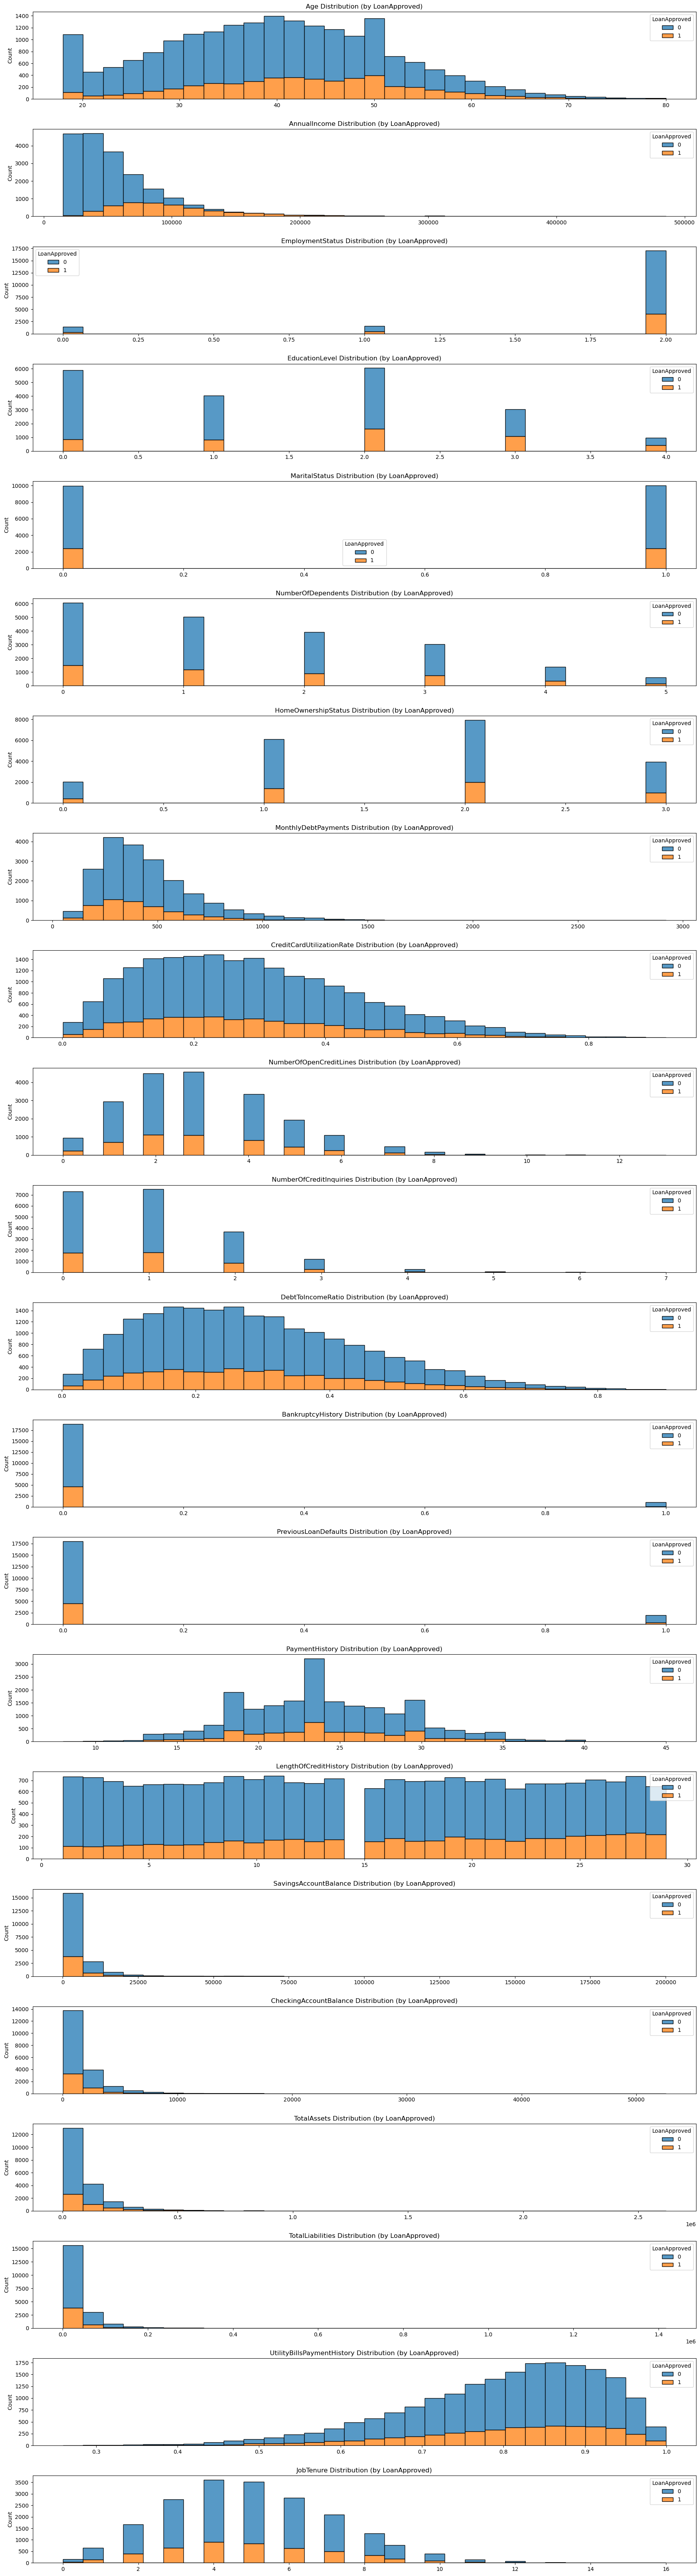

In [85]:
numeric_columns = data.select_dtypes(include=['float64', 'int64']).drop(columns=['LoanApproved']).columns


mp.figure(figsize=(18, len(numeric_columns)*3))

for i, col in enumerate(numeric_columns):
    mp.subplot(len(numeric_columns), 1, i + 1)
    sb.histplot(data=data, x=col, hue='LoanApproved', multiple="stack", bins=30)
    mp.title(f"{col} Distribution (by LoanApproved)")
    mp.xlabel("")
    mp.tight_layout()

mp.show()


#### What I observed after examining the distribution plots:

-   ##### Encoding EmploymentStatus numerically in an ordinal manner was the right decision.

-   ##### My numerical encoding of EducationLevel also allows me to observe meaningful differences.

-   ##### Variables such as BankruptcyHistory, PreviousLoanDefaults, and NumberOfCreditInquiries have a high degree of influence on LoanApproval.

#### LoanApproval Distribution Check

In [86]:
data["LoanApproved"].value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

```
LoanApproved
0    15220
1     4780
Name: count, dtype: int64
```

##### We have an inbalanced Classification probelm

##### 

## Modeling Phase

In [87]:
y = data["LoanApproved"]
x = data.drop(["LoanApproved"],axis = 1)

In [88]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y  # to ensure balanced distribution of LoanApproved values
)

### Logistic Regression 

In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score


model = LogisticRegression(solver='liblinear',class_weight='balanced', max_iter=1000) # The reason for class_weight='balanced' is
                                                                                      # LoanApproved is distributed approximately 25% to 75% 
model.fit(x_train_scaled, y_train)                                                    # this imbalanced distribution.

y_pred = model.predict(x_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
cross_val_score(model,x_test_scaled,y_test,cv = 10).mean()
accuracy_score(y_test,y_pred)


[[2614  430]
 [ 155  801]]
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      3044
           1       0.65      0.84      0.73       956

    accuracy                           0.85      4000
   macro avg       0.80      0.85      0.82      4000
weighted avg       0.87      0.85      0.86      4000



0.85375

```
0.85375
```

##### We can see that AccuracyScore, F1-score, and cross-validation score are all around 0.85.

#### ROC AUC Curves

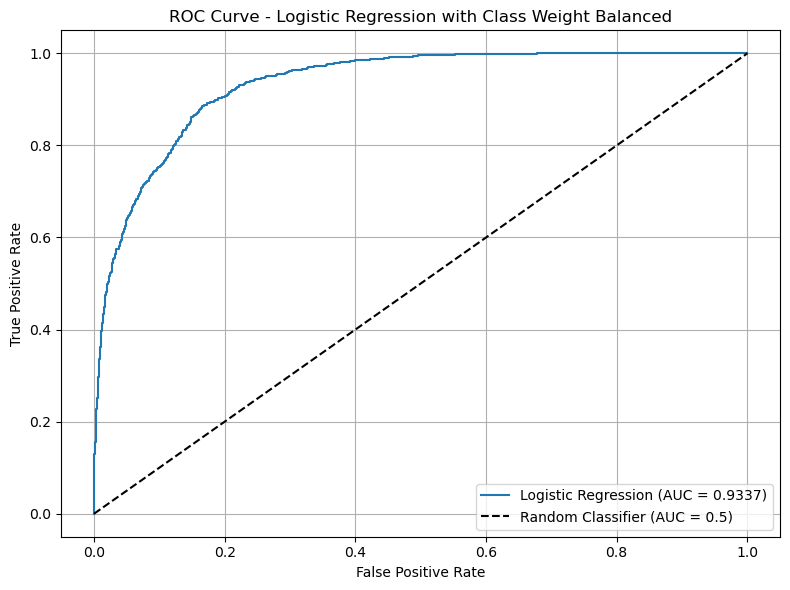

In [91]:
from sklearn.metrics import roc_curve
y_proba = model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Plot
mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - Logistic Regression with Class Weight Balanced')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### NAIVE BAYES

In [92]:
from sklearn.naive_bayes import GaussianNB

In [93]:
naive_model = GaussianNB().fit(x_train_scaled,y_train)
preds_naive = naive_model.predict(x_test_scaled)
accuracy_score(y_test,preds_naive)
print(confusion_matrix(y_test, preds_naive))
print(classification_report(y_test, preds_naive))
accuracy_score(y_test,preds_naive),cross_val_score(naive_model,x_test_scaled,y_test,cv = 10).mean()


[[2860  184]
 [ 378  578]]
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      3044
           1       0.76      0.60      0.67       956

    accuracy                           0.86      4000
   macro avg       0.82      0.77      0.79      4000
weighted avg       0.85      0.86      0.85      4000



(0.8595, np.float64(0.8522500000000001))

```
(0.8595, 0.8522500000000001)
```

##### Cross-validation, F1-score, and Accuracy are all approximately 0.86

#### ROC AUC Curves

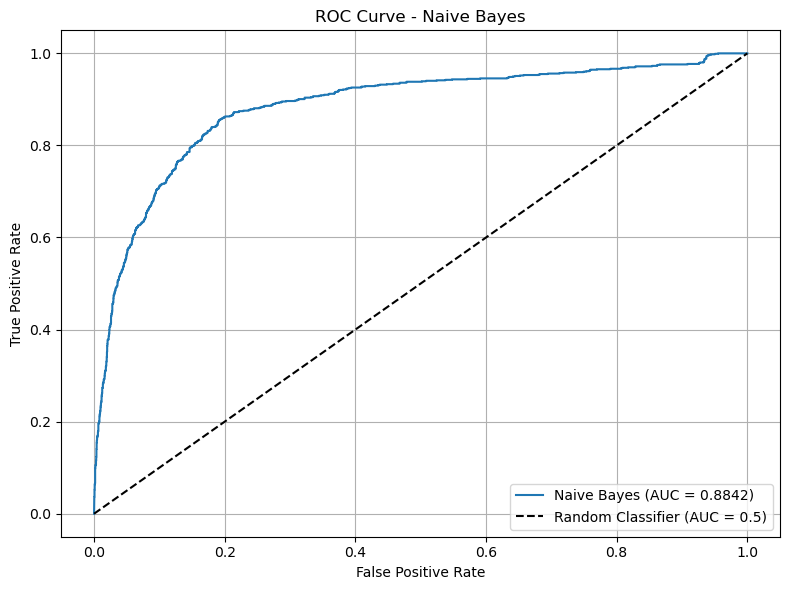

In [94]:
y_proba =naive_model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Plot
mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'Naive Bayes (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - Naive Bayes')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### KNN

In [95]:
from sklearn.neighbors import KNeighborsClassifier

In [96]:
knn_model = KNeighborsClassifier().fit(x_train_scaled,y_train)
preds_knn = knn_model.predict(x_test_scaled)

In [97]:
print(confusion_matrix(y_test, preds_knn))
print(classification_report(y_test, preds_knn))
accuracy_score(y_test,preds_knn),cross_val_score(knn_model,x_test_scaled,y_test,cv = 10).mean()


[[2905  139]
 [ 589  367]]
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      3044
           1       0.73      0.38      0.50       956

    accuracy                           0.82      4000
   macro avg       0.78      0.67      0.70      4000
weighted avg       0.81      0.82      0.80      4000



(0.818, np.float64(0.8127500000000001))

```
(0.818, 0.8127500000000001)
```

In [98]:
knn_params = {'n_neighbors': np.arange(1,40)}
knn_mod = KNeighborsClassifier()
gs_knn = GridSearchCV(knn_mod,knn_params,cv = 10,n_jobs = -1).fit(x_train_scaled,y_train)

/Users/furkancanercan/anaconda3/envs/pythonb/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/furkancanercan/anaconda3/envs/pythonb/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/furkancanercan/anaconda3/envs/pythonb/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early a

In [99]:
gs_knn.best_params_

{'n_neighbors': np.int64(11)}

```
{'n_neighbors': 11}
```

#### After Model Optimization

In [100]:
knn_best = KNeighborsClassifier(n_neighbors = 11).fit(x_train_scaled,y_train)
best_preds_knn = knn_best.predict(x_test_scaled)
print(confusion_matrix(y_test, best_preds_knn))
print(classification_report(y_test, best_preds_knn))
accuracy_score(y_test,best_preds_knn)


[[2977   67]
 [ 643  313]]
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      3044
           1       0.82      0.33      0.47       956

    accuracy                           0.82      4000
   macro avg       0.82      0.65      0.68      4000
weighted avg       0.82      0.82      0.79      4000



0.8225

```
0.8225
```

###### There is a near 1% improvement in Accuracy Score

#### ROC AUC Curves

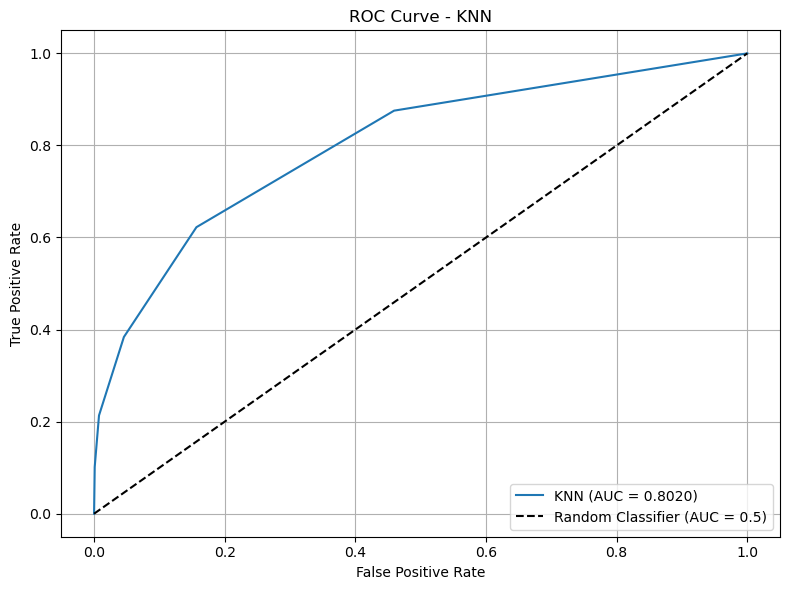

In [101]:
y_proba =knn_model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Plot
mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'KNN (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - KNN')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### LINEAR SVM

In [102]:
from sklearn.svm import SVC

In [103]:
svm_model = SVC(kernel = 'linear',probability=True).fit(x_train_scaled,y_train)
svm_preds = svm_model.predict(x_test_scaled)
print(confusion_matrix(y_test, svm_preds))
print(classification_report(y_test, svm_preds))
accuracy_score(y_test,svm_preds)


[[2897  147]
 [ 352  604]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3044
           1       0.80      0.63      0.71       956

    accuracy                           0.88      4000
   macro avg       0.85      0.79      0.81      4000
weighted avg       0.87      0.88      0.87      4000



0.87525

```
0.87525
```

In [104]:
svm_params = {'C':np.arange(1,15)}
svm_mod = SVC(kernel = 'linear')
gs_svm = GridSearchCV(svm_mod,svm_params,cv = 5,n_jobs = -1).fit(x_train_scaled,y_train)
gs_svm.best_params_

{'C': np.int64(1)}

```
{'C': 9}
```

#### After Parameter Optimization

In [105]:
svm_best_model = SVC(kernel='linear',C = 9,probability=True).fit(x_train_scaled,y_train)
svm_best_preds = svm_best_model.predict(x_test_scaled)
print(confusion_matrix(y_test,svm_best_preds))
print(classification_report(y_test, svm_best_preds))
accuracy_score(y_test,svm_best_preds)


[[2897  147]
 [ 352  604]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3044
           1       0.80      0.63      0.71       956

    accuracy                           0.88      4000
   macro avg       0.85      0.79      0.81      4000
weighted avg       0.87      0.88      0.87      4000



0.87525

```
0.8755
```

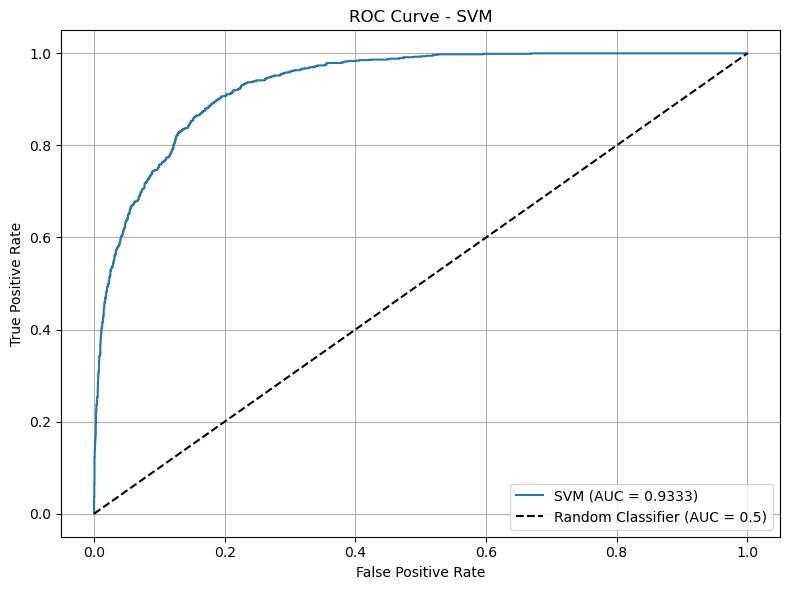

In [106]:
y_proba = svm_best_model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - SVM')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### NON-LINEAR SVM

In [107]:
svm_model = SVC(kernel='rbf').fit(x_train_scaled,y_train)
svm_preds = svm_model.predict(x_test_scaled)
print(confusion_matrix(y_test, svm_preds))
print(classification_report(y_test, svm_preds))
print(accuracy_score(y_test,svm_preds))


[[2889  155]
 [ 365  591]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3044
           1       0.79      0.62      0.69       956

    accuracy                           0.87      4000
   macro avg       0.84      0.78      0.81      4000
weighted avg       0.86      0.87      0.86      4000

0.87


In [108]:
svm_params = {'C':[0.1,1,10],'gamma':[0.01,0.1,5,10]}
scm_mod = SVC(kernel='rbf')
gs_svm = GridSearchCV(svm_mod, svm_params, cv = 5,n_jobs = -1).fit(x_train_scaled,y_train)
gs_svm.best_params_

{'C': 0.1, 'gamma': 0.01}

```
{'C': 0.1, 'gamma': 0.01}
```

#### After Parameter Optimization

In [109]:
svm_best_model = SVC(kernel = 'rbf', C = 0.1, gamma = 0.01,probability=True).fit(x_train_scaled,y_train)
svm_best_preds = svm_best_model.predict(x_test_scaled)

```
0.86675
```



#### ROC AUC Curves

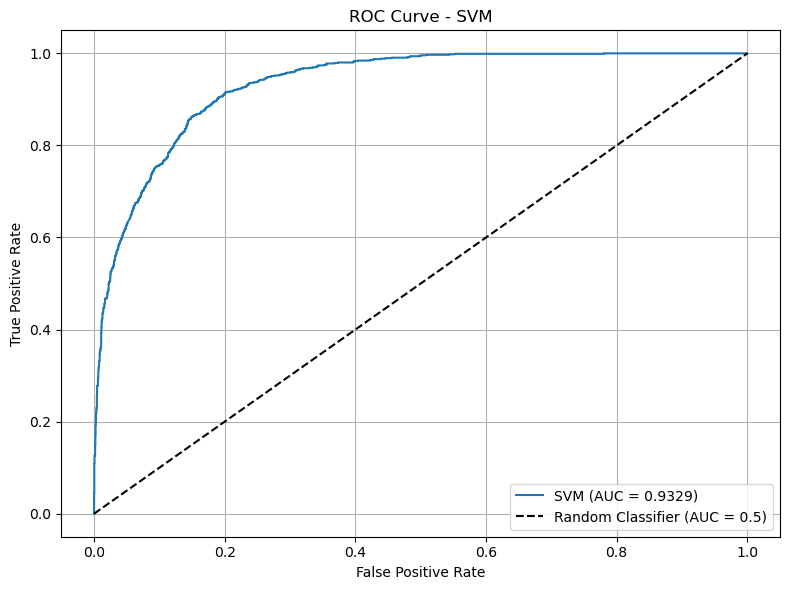

In [110]:
y_proba = svm_best_model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - SVM')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### ARTIFICIAL NEURAL NETWORKS (ANN)

In [111]:
from sklearn.neural_network import MLPClassifier

In [112]:
ann_model = MLPClassifier().fit(x_train_scaled,y_train)
ann_preds = ann_model.predict(x_test_scaled)
print(confusion_matrix(y_test, ann_preds))
print(classification_report(y_test, ann_preds))
print(accuracy_score(y_test,ann_preds))


[[2744  300]
 [ 289  667]]
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      3044
           1       0.69      0.70      0.69       956

    accuracy                           0.85      4000
   macro avg       0.80      0.80      0.80      4000
weighted avg       0.85      0.85      0.85      4000

0.85275


In [113]:
ann_params = {
    'alpha': [0.0001, 0.001, 0.01],
    'hidden_layer_sizes': [(64,), (64, 64), (128, 64)],
    'solver': ['adam'],
    'activation': ['relu']
}

ann_mod = MLPClassifier(max_iter=500, early_stopping=True)
gs_ann = GridSearchCV(ann_mod, ann_params, cv = 5).fit(x_train_scaled,y_train)
gs_ann.best_params_

{'activation': 'relu',
 'alpha': 0.0001,
 'hidden_layer_sizes': (128, 64),
 'solver': 'adam'}

```
{'activation': 'relu',
 'alpha': 0.001,
 'hidden_layer_sizes': (64,),
 'solver': 'adam'}
```

#### After Model Optimization

In [114]:
ann_best_model = MLPClassifier(activation='relu', alpha = 0.001,
                               hidden_layer_sizes = (64,),
                               solver = 'adam').fit(x_train_scaled,y_train)
ann_best_pred = ann_best_model.predict(x_test_scaled)
print(confusion_matrix(y_test, ann_best_pred))
print(classification_report(y_test, ann_best_pred))
print(accuracy_score(y_test,ann_best_pred))



[[2809  235]
 [ 318  638]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      3044
           1       0.73      0.67      0.70       956

    accuracy                           0.86      4000
   macro avg       0.81      0.80      0.80      4000
weighted avg       0.86      0.86      0.86      4000

0.86175


#### ROC AUC Curves

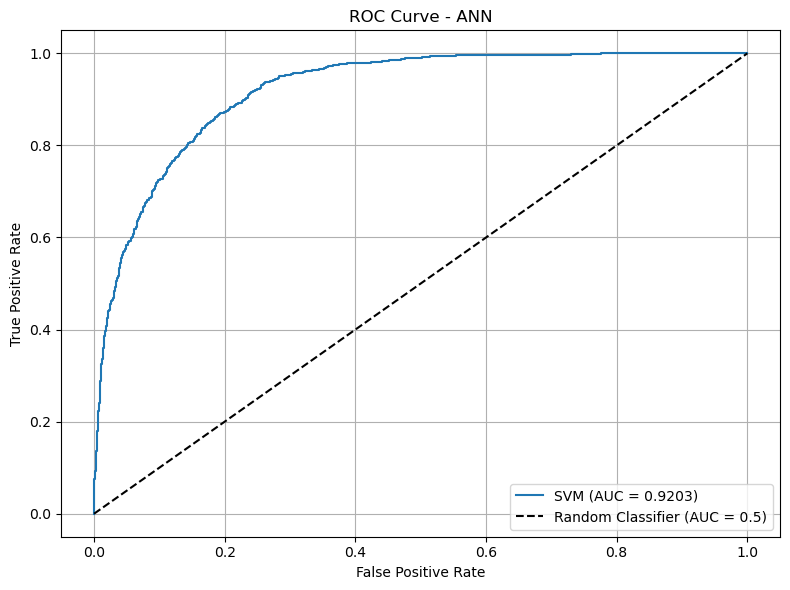

In [115]:
y_proba = ann_best_model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - ANN')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### CART

In [116]:
from sklearn.tree import DecisionTreeClassifier

In [117]:
cart_model = DecisionTreeClassifier().fit(x_train_scaled,y_train)
cart_preds = cart_model.predict(x_test_scaled)
print(confusion_matrix(y_test, cart_preds))
print(classification_report(y_test, cart_preds))
print(accuracy_score(y_test,cart_preds))


[[2666  378]
 [ 402  554]]
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      3044
           1       0.59      0.58      0.59       956

    accuracy                           0.81      4000
   macro avg       0.73      0.73      0.73      4000
weighted avg       0.80      0.81      0.80      4000

0.805


In [118]:
cart_params = {'max_depth':list(range(1,10)),
               'min_samples_split':list(range(2,60))}
cart_mod = DecisionTreeClassifier()
gs_cart = GridSearchCV(cart_mod, cart_params, cv= 5,n_jobs = -1).fit(x_train_scaled,y_train)
print(gs_cart.best_params_)

{'max_depth': 5, 'min_samples_split': 47}

{'max_depth': 5, 'min_samples_split': 47}


{'max_depth': 5, 'min_samples_split': 47}

#### After Model Optimization

In [119]:
cart_model_best = DecisionTreeClassifier(max_depth = 5,
                                         min_samples_split = 47).fit(x_train_scaled,y_train)
cart_preds_best = cart_model_best.predict(x_test_scaled)
print(confusion_matrix(y_test, cart_preds_best))
print(classification_report(y_test, cart_preds_best))
print(accuracy_score(y_test,cart_preds_best))


[[2881  163]
 [ 441  515]]
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      3044
           1       0.76      0.54      0.63       956

    accuracy                           0.85      4000
   macro avg       0.81      0.74      0.77      4000
weighted avg       0.84      0.85      0.84      4000

0.849



#### ROC AUC Curves

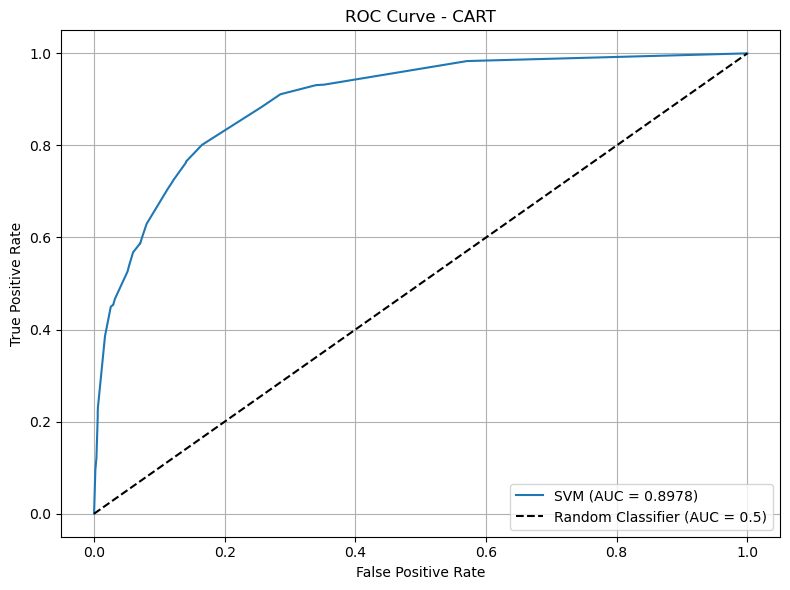

In [120]:
y_proba = cart_model_best.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - CART')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### RANDOM FOREST

In [121]:
from sklearn.ensemble import RandomForestClassifier

In [122]:
rf_model = RandomForestClassifier().fit(x_train_scaled,y_train)
rf_preds = rf_model.predict(x_test_scaled)
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))
print(accuracy_score(y_test,rf_preds))


[[2881  163]
 [ 366  590]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3044
           1       0.78      0.62      0.69       956

    accuracy                           0.87      4000
   macro avg       0.84      0.78      0.80      4000
weighted avg       0.86      0.87      0.86      4000

0.86775



#### Since GridSearchCV takes too long to run, RandomizedSearchCV will be used instead.

In [123]:
from sklearn.model_selection import RandomizedSearchCV

rf_mod = RandomForestClassifier()
rf_params = {
    'max_depth': [2, 5, 8, 10],
    'max_features': [2, 5, 8, 10],
    'n_estimators': [10, 100, 200],
    'min_samples_split': [2, 5, 8, 10]
}

rs_rf = RandomizedSearchCV(rf_mod, rf_params, n_iter=20, cv=5, n_jobs=-1)
rs_rf.fit(x_train_scaled, y_train)
print(rs_rf.best_params_)

{'n_estimators': 200, 'min_samples_split': 8, 'max_features': 8, 'max_depth': 10}

{'n_estimators': 100, 'min_samples_split': 10, 'max_features': 8, 'max_depth': 8}


{'n_estimators': 200,
 'min_samples_split': 8,
 'max_features': 8,
 'max_depth': 10}

#### After Model Optimization

In [124]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=8,
    max_features=8,
    max_depth=10,
    random_state=42  
).fit(x_train_scaled, y_train)
best_rf_preds = best_rf.predict(x_test_scaled)
print(confusion_matrix(y_test, best_rf_preds))
print(classification_report(y_test, best_rf_preds))
print(accuracy_score(y_test,best_rf_preds))


[[2878  166]
 [ 362  594]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3044
           1       0.78      0.62      0.69       956

    accuracy                           0.87      4000
   macro avg       0.83      0.78      0.80      4000
weighted avg       0.86      0.87      0.86      4000

0.868


#### ROC AUC Curves

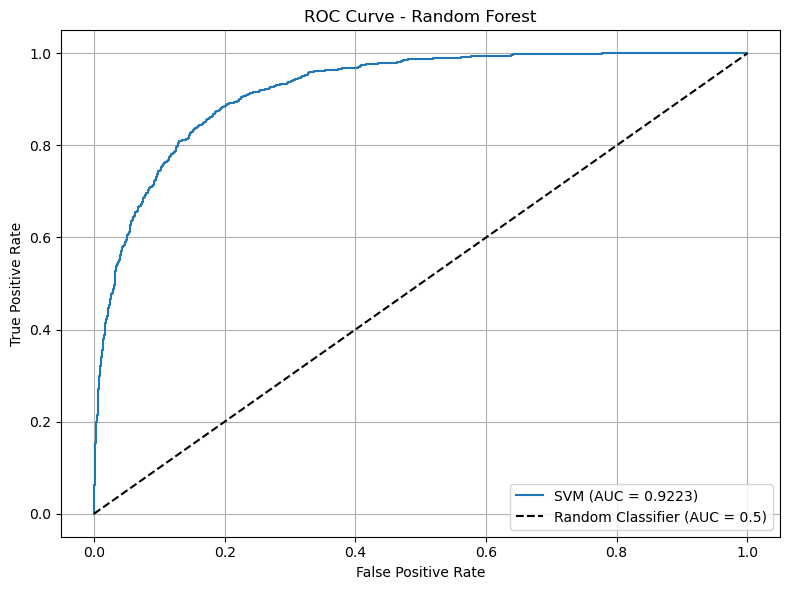

In [125]:
y_proba = best_rf.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - Random Forest')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### GRADIENT BOOSTING

In [126]:
from sklearn.ensemble import GradientBoostingClassifier

In [127]:
gb_model = GradientBoostingClassifier().fit(x_train_scaled,y_train)
gb_preds = gb_model.predict(x_test_scaled)
print(confusion_matrix(y_test, gb_preds))
print(classification_report(y_test, gb_preds))
print(accuracy_score(y_test,gb_preds))


[[2863  181]
 [ 331  625]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      3044
           1       0.78      0.65      0.71       956

    accuracy                           0.87      4000
   macro avg       0.84      0.80      0.81      4000
weighted avg       0.87      0.87      0.87      4000

0.872


In [128]:
gb_params = {'learning_rate':[0.001,0.01,0.1],
             'n_estimators':[50,100,250],
             'min_samples_split':[2,7,10]}
gb_mod = GradientBoostingClassifier()
gs_gb = GridSearchCV(gb_mod, gb_params, cv = 5, n_jobs = -1).fit(x_train_scaled,y_train)
gs_gb.best_params_

{'learning_rate': 0.1, 'min_samples_split': 2, 'n_estimators': 100}

```
{'learning_rate': 0.1, 'min_samples_split': 2, 'n_estimators': 100}
```

#### After Model Optimization

In [129]:
gb_best = GradientBoostingClassifier(learning_rate = 0.1,
                                     min_samples_split = 2,
                                     n_estimators = 100).fit(x_train_scaled,y_train)
gb_best_preds = gb_best.predict(x_test_scaled)
print(confusion_matrix(y_test, gb_best_preds))
print(classification_report(y_test, gb_best_preds))
print(accuracy_score(y_test,gb_best_preds))


[[2863  181]
 [ 331  625]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      3044
           1       0.78      0.65      0.71       956

    accuracy                           0.87      4000
   macro avg       0.84      0.80      0.81      4000
weighted avg       0.87      0.87      0.87      4000

0.872



#### ROC AUC Curves

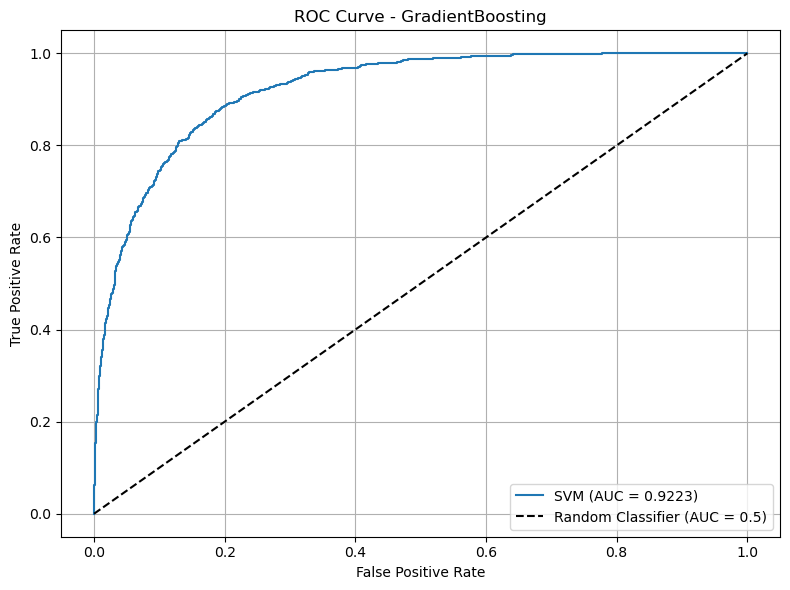

In [130]:
y_proba = best_rf.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - GradientBoosting')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### XGBOOST

In [132]:
from xgboost import XGBClassifier

In [133]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train_scaled, y_train)
xgb_preds = xgb_model.predict(x_test_scaled)
print(confusion_matrix(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))
print(accuracy_score(y_test,xgb_preds))




[[2816  228]
 [ 321  635]]
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      3044
           1       0.74      0.66      0.70       956

    accuracy                           0.86      4000
   macro avg       0.82      0.79      0.80      4000
weighted avg       0.86      0.86      0.86      4000

0.86275


In [134]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5]
}

xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

grid_xgb = GridSearchCV(xgb_base, param_grid, cv=5, n_jobs=-1)
grid_xgb.fit(x_train_scaled, y_train)

grid_xgb.best_params_

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 1,
 'n_estimators': 100}

```
{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 1,
 'n_estimators': 100}
```

#### After Model Optimization

In [135]:
best_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_child_weight=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

best_xgb.fit(x_train_scaled, y_train)
xgb_preds_best = best_xgb.predict(x_test_scaled)
print(confusion_matrix(y_test, xgb_preds_best))
print(classification_report(y_test, xgb_preds_best))
print(accuracy_score(y_test,xgb_preds_best))



[[2861  183]
 [ 327  629]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      3044
           1       0.77      0.66      0.71       956

    accuracy                           0.87      4000
   macro avg       0.84      0.80      0.81      4000
weighted avg       0.87      0.87      0.87      4000

0.8725


###### A small improvement was observed as a result of Model Optimization.

#### ROC AUC Curves

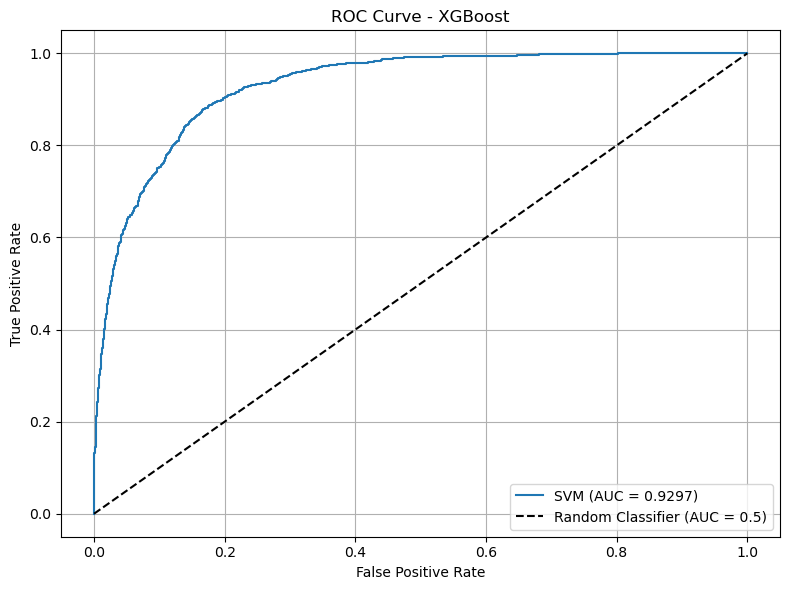

In [136]:
y_proba = best_xgb.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

mp.figure(figsize=(8, 6))
mp.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.4f})')
mp.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC Curve - XGBoost')
mp.legend(loc='lower right')
mp.grid()
mp.tight_layout()
mp.show()

### Comparing the Model Performances

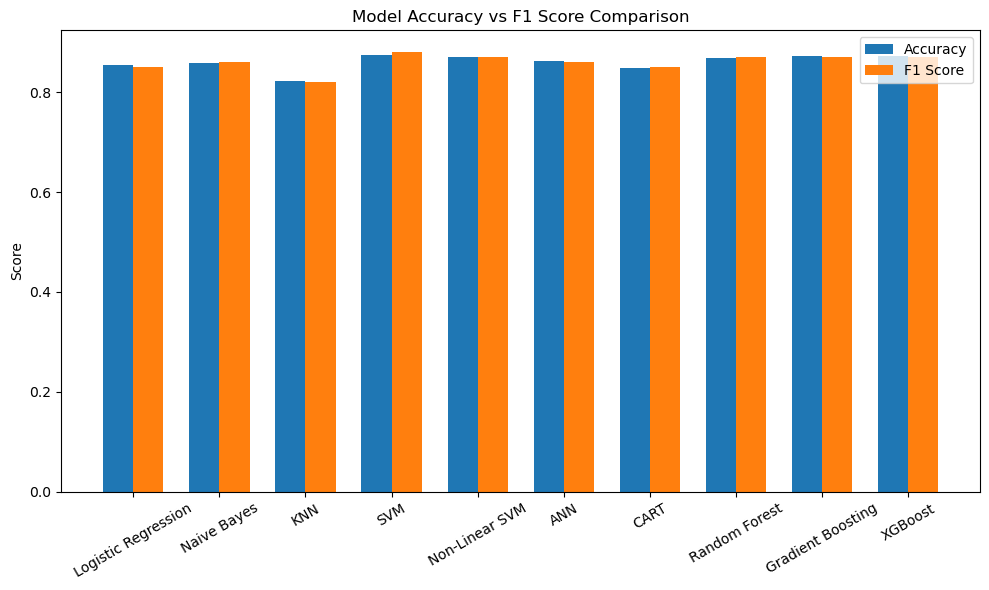

In [137]:
model_names = ["Logistic Regression", "Naive Bayes", "KNN","SVM","Non-Linear SVM","ANN","CART", "Random Forest", "Gradient Boosting", "XGBoost"]
accuracy_scores = [0.85375, 0.8595, 0.8225, 0.8755, 0.87, 0.86275,0.8485,0.8695,0.872,0.8725]
f1_scores = [0.85, 0.86, 0.82, 0.88, 0.87, 0.86,0.85,0.87,0.87,0.87]

x = range(len(model_names))
width = 0.35

mp.figure(figsize=(10, 6))
mp.bar(x, accuracy_scores, width=width, label='Accuracy')
mp.bar([i + width for i in x], f1_scores, width=width, label='F1 Score')

mp.xticks([i + width/2 for i in x], model_names, rotation=30)
mp.ylabel('Score')
mp.title('Model Accuracy vs F1 Score Comparison')
mp.legend()
mp.tight_layout()
mp.show()



#### The selected Accuracy and F1-Score metrics were compared before and after Parameter Optimization for each model, and the best-performing combinations were included in the chart.

### * Based On Accuracy and F1-Score best performing model is Parameter Optimized SVM Lineer

In [ ]: